<a href="https://colab.research.google.com/github/mariibonilla22-collab/Phyton-Data-Analytics/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"
df = pd.read_csv(url)

In [ ]:
df.columns = df.columns.str.strip()
numeric_cols = [
    "Mean Score",
    "Total Tested",
    "Percent Scoring 65 or Above",
    "Percent Scoring 80 or Above",
]

for col in numeric_cols:
  if col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df_clean = df.dropna(subset=["Mean Score"]).copy()

print("--- DATASET GENERAL OVERVIEW ---")
print(f"Total Rows Processed: {len(df_clean)}")
print(f"Unique Schools: {df_clean['School Name'].nunique()}")
print(f"Unique Regents Exams: {df_clean['Regents Exam'].nunique()}\n")

--- DATASET GENERAL OVERVIEW ---
Total Rows Processed: 137109
Unique Schools: 965
Unique Regents Exams: 14



In [ ]:
# Question 1: What is the overall citywide average score?
overall_avg = df_clean["Mean Score"].mean()
print(f"1. What is the citywide average Mean Score?: {overall_avg:.2f}")

1. What is the citywide average Mean Score?: 66.00


In [ ]:
# Question 2: Which top 3 Regents exams had the most total students tested?
top_exams_tested = (
    df_clean.groupby("Regents Exam")["Total Tested"]
    .sum()
    .nlargest(3)
    .to_dict()
)
print(f"2. Top 3 exams by total students tested: {top_exams_tested}")

2. Top 3 exams by total students tested: {'Common Core Algebra': 1484759, 'Global History and Geography': 1394846, 'Living Environment': 1350730}


In [ ]:
# Question 3: Which top 5 schools achieved the highest average Mean Score?
top_5_schools = (
    df_clean.groupby("School Name")["Mean Score"].mean().nlargest(5)
)
print(
    f"3. Top 5 schools with highest mean scores: {list(top_5_schools.index)}"
)

3. Top 5 schools with highest mean scores: ['Stuyvesant High School', 'J.H.S. 185 Edward Bleeker', 'The Anderson School', 'The Christa McAuliffe School\\I.S. 187', 'East Side Middle School']


In [ ]:
# 4. Comparative Statistics across Exams
print("\n--- COMPARATIVE STATISTICS ---")
exam_stats = (
    df_clean.groupby("Regents Exam")["Mean Score"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
)
print(exam_stats.head(10))


--- COMPARATIVE STATISTICS ---
                              count   mean    std   min   max
Regents Exam                                                 
Algebra2/Trigonometry          5432  56.37  13.34  19.1  95.2
Common Core Algebra           19549  67.49   9.89  37.2  96.6
Common Core Algebra2           4358  63.59   9.31  33.6  90.9
Common Core English           13319  70.38  11.86  15.0  98.3
Common Core Geometry           9546  59.11  10.10  27.0  92.1
English                        6784  65.77   9.98  30.7  95.1
Geometry                       4347  61.88  10.74  29.0  95.1
Global History and Geography  14713  64.17  10.64  28.7  97.0
Integrated Algebra             6308  64.81   7.07  36.7  95.9
Living Environment            18243  69.06   9.89  36.5  96.8


In [ ]:
# 5. Visualizations for Capstone Presentation
sns.set_theme(style="whitegrid")

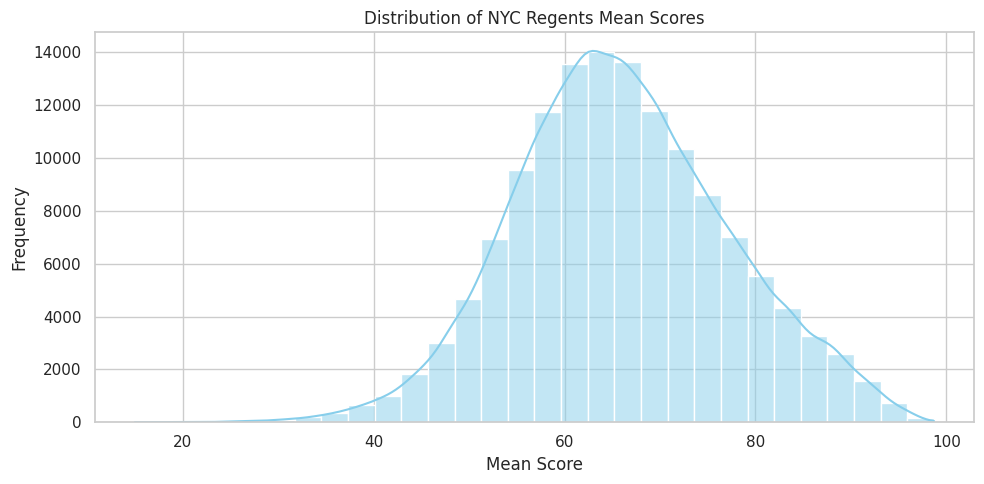

In [ ]:
# Visualization 1: Distribution of Mean Scores
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["Mean Score"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of NYC Regents Mean Scores")
plt.xlabel("Mean Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

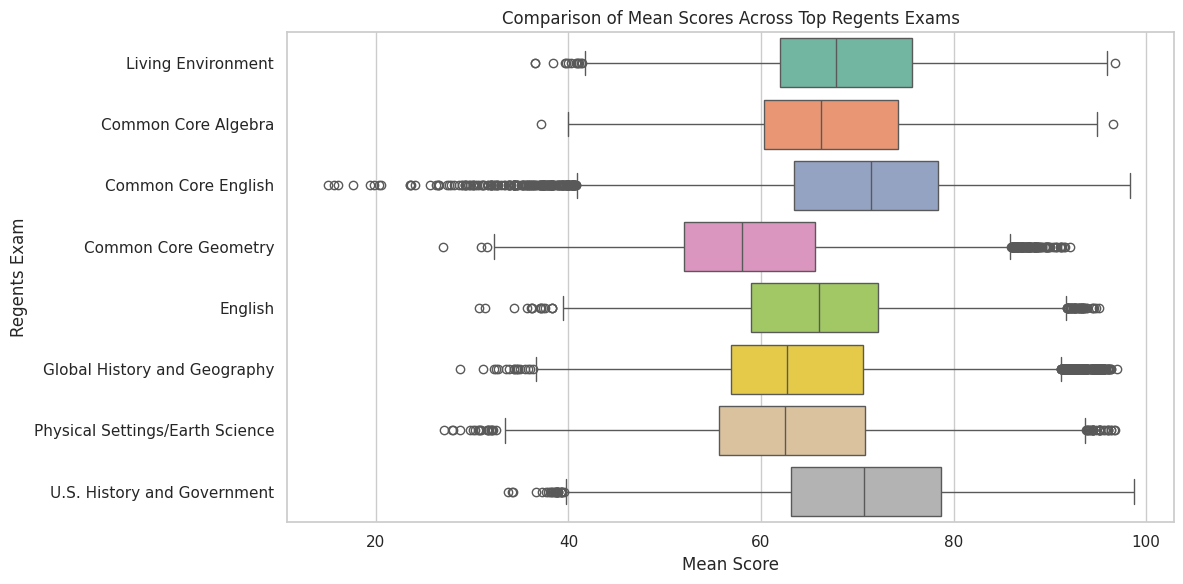

In [ ]:
# Visualization 2: Comparison of Mean Scores Across Top 8 Exams
plt.figure(figsize=(12, 6))
top_8_exams = df_clean["Regents Exam"].value_counts().nlargest(8).index
df_top_exams = df_clean[df_clean["Regents Exam"].isin(top_8_exams)]

sns.boxplot(
    data=df_top_exams,
    x="Mean Score",
    y="Regents Exam",
    palette="Set2",
    hue="Regents Exam",
    legend=False,
)
plt.title("Comparison of Mean Scores Across Top Regents Exams")
plt.xlabel("Mean Score")
plt.ylabel("Regents Exam")
plt.tight_layout()
plt.show()

In [ ]:
# 6. Conclusion Statement (Printed and exported to text file)
conclusion_text = (
    "CAPSTONE CONCLUSION STATEMENT:\n"
    "The analysis of NYC Regents exam data reveals significant variance in student performance "
    "across subject areas and individual school facilities. These empirical insights highlight "
    "persistent academic disparities, providing a data-driven baseline to guide targeted "
    "educational interventions and equitable resource allocation."
)

print("\n" + "=" * 80)
print(conclusion_text)
print("=" * 80)

# Save conclusion to a .txt file automatically
with open("conclusion.txt", "w") as f:
  f.write(conclusion_text)

print("\nConclusion exported successfully to 'conclusion.txt'!")


CAPSTONE CONCLUSION STATEMENT:
The analysis of NYC Regents exam data reveals significant variance in student performance across subject areas and individual school facilities. These empirical insights highlight persistent academic disparities, providing a data-driven baseline to guide targeted educational interventions and equitable resource allocation.

Conclusion exported successfully to 'conclusion.txt'!
